# Nodal LMP vs. Redispatch Battery-Siting Score — 2025 hourly 20-node run

**Goal.** The battery siting score is a *proxy* for the locational price signal that
Germany's single bidding zone hides. This notebook uses the **real** nodal marginal
prices from the PyPSA `de-nodal-2025-hourly` run (20 clusters, **10 German nodes**, hourly,
year 2025) to check whether the locations the proxy scores as high-value are
the same ones where the nodal model shows a strong battery-arbitrage / congestion signal.

Compared file: `battery_siting_score/out/grid_siting_scores_20260629_155333.csv`
(50 MW / 4 h reference battery, `dV_proxy_eur_per_year` = locational value premium).

Because resolutions differ (siting = 4,593 cells on a 0.1° grid; PyPSA = 10 DE nodes),
each siting cell is assigned to its **nearest PyPSA node**, then aggregated.
Only the **ranking** is comparable, not absolute €.

In [1]:
import netCDF4 as nc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10

NET   = "de-nodal-2025-hourly/networks/base_s_20_elec_.nc"
SITE  = "../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"
PMW, DUR = 50.0, 4.0          # reference battery: 50 MW / 4 h

## 1. Load PyPSA nodal prices and keep German nodes

In [2]:
ds = nc.Dataset(NET)
rs = lambda n:(list(nc.chartostring(ds.variables[n][:]))
               if ds.variables[n][:].dtype.kind in 'SU' else ds.variables[n][:])
bus=[str(b) for b in rs('buses_i')]; X,Y=rs('buses_x'),rs('buses_y')
ctry=[str(c) for c in rs('buses_country')]
mp=np.array(ds.variables['buses_t_marginal_price'][:]); mp_i=[str(b) for b in rs('buses_t_marginal_price_i')]
ds.close()
if mp.shape[0]==len(mp_i): mp=mp.T
price=pd.DataFrame(mp,columns=mp_i)
de=[b for b,c in zip(bus,ctry) if c=='DE']
T=price.shape[0]; dt=8760/T; steps_per_day=int(round(24/dt))
print(f"snapshots={T}  dt={dt:.1f} h  steps/day={steps_per_day}  DE nodes={len(de)}")
price[de].describe().T[['mean','std','min','max']].round(2)

snapshots=8760  dt=1.0 h  steps/day=24  DE nodes=10


,mean,std,min,max
DE0 0AC,27.90,3.14,22.12,43.86
DE0 1AC,26.58,4.62,0.02,43.82
DE0 2AC,26.81,4.11,0.19,43.69
DE0 3AC,26.54,4.47,2.98,43.87
DE0 4AC,28.25,3.11,22.12,44.06
DE0 5AC,26.52,4.55,0.03,43.79
DE0 6AC,26.71,4.19,4.82,43.81
DE0 7AC,27.15,3.65,18.97,43.75
DE0 8AC,27.05,3.86,7.94,43.84
DE0 9AC,26.28,4.83,0.03,43.82


## 2. Per-node battery value from the nodal price

A dt-aware greedy arbitrage: each day, charge the cheapest steps (up to power limit
`PMW*dt` per step and energy cap `PMW*DUR`) and discharge the dearest steps. This is the
nodal-price analog of the siting score's `dV`. We also record price mean, volatility and
each node's congestion premium (deviation from the German mean price).

In [3]:
E_CAP=PMW*DUR; E_STEP=PMW*dt
def daily_arb(day):                      # day = array of step prices
    order=np.argsort(day)
    lo,hi=order[:len(order)//2], order[len(order)//2:][::-1]
    e=0.0; buy=0.0
    for s in lo:
        if e>=E_CAP: break
        q=min(E_STEP,E_CAP-e); buy+=q*day[s]; e+=q
    e=0.0; sell=0.0
    for s in hi:
        if e>=E_CAP: break
        q=min(E_STEP,E_CAP-e); sell+=q*day[s]; e+=q
    return sell-buy                      # € profit that day

recs=[]
for b in de:
    p=price[b].values[:T//steps_per_day*steps_per_day].reshape(-1,steps_per_day)
    prof=np.array([daily_arb(d) for d in p])
    arb=prof.sum()*(365/len(prof))       # €/yr
    i=bus.index(b)
    recs.append(dict(bus=b,x=float(X[i]),y=float(Y[i]),
                     mean_price=price[b].mean(),std_price=price[b].std(),
                     p95_p5_spread=np.percentile(price[b],95)-np.percentile(price[b],5),
                     arb_eur_yr=arb))
nod=pd.DataFrame(recs)
nod['congestion_premium']=nod['mean_price']-price[de].values.mean()
nod.sort_values('arb_eur_yr',ascending=False).round(2)

,bus,x,y,mean_price,std_price,p95_p5_spread,arb_eur_yr,congestion_premium
9,DE0 9AC,9.73,53.89,26.28,4.83,17.04,366537.66,-0.70
5,DE0 5AC,8.21,52.52,26.52,4.55,16.33,338359.78,-0.46
1,DE0 1AC,10.29,51.91,26.58,4.62,16.13,333128.33,-0.40
3,DE0 3AC,13.20,52.98,26.54,4.47,16.35,331831.84,-0.43
2,DE0 2AC,7.06,51.18,26.81,4.11,14.72,310134.96,-0.17
6,DE0 6AC,13.14,51.23,26.71,4.19,16.11,307238.42,-0.27
8,DE0 8AC,10.99,50.12,27.05,3.86,15.34,279314.53,0.07
7,DE0 7AC,8.38,49.62,27.15,3.65,14.58,269633.61,0.17
4,DE0 4AC,11.96,48.48,28.25,3.11,11.27,221062.14,1.27
0,DE0 0AC,9.24,48.46,27.90,3.14,11.73,209158.85,0.92


## 3. Aggregate the siting surface to the nearest PyPSA node

In [4]:
sit=pd.read_csv(SITE); print("siting grid cells:",len(sit))
nx,ny=nod['x'].values,nod['y'].values
sit['pypsa_bus']=[nod['bus'].values[((nx-lo)**2+(ny-la)**2).argmin()]
                  for lo,la in zip(sit['lon'],sit['lat'])]
agg=(sit.groupby('pypsa_bus')
        .agg(n_cells=('lon','size'),sit_V=('V_proxy_eur_per_year','mean'),
             sit_dV=('dV_proxy_eur_per_year','mean')).reset_index())
m=nod.merge(agg,left_on='bus',right_on='pypsa_bus').drop(columns='pypsa_bus')
m.sort_values('sit_dV',ascending=False).round(2)

siting grid cells: 4593


,bus,x,y,mean_price,std_price,p95_p5_spread,arb_eur_yr,congestion_premium,n_cells,sit_V,sit_dV
6,DE0 6AC,13.14,51.23,26.71,4.19,16.11,307238.42,-0.27,439,18850245.94,12427933.42
8,DE0 8AC,10.99,50.12,27.05,3.86,15.34,279314.53,0.07,452,16678313.86,10256001.34
1,DE0 1AC,10.29,51.91,26.58,4.62,16.13,333128.33,-0.40,519,15462999.34,9040686.82
3,DE0 3AC,13.20,52.98,26.54,4.47,16.35,331831.84,-0.43,592,13835091.42,7412778.90
9,DE0 9AC,9.73,53.89,26.28,4.83,17.04,366537.66,-0.70,415,13813366.05,7391053.53
7,DE0 7AC,8.38,49.62,27.15,3.65,14.58,269633.61,0.17,435,13361054.42,6938741.90
5,DE0 5AC,8.21,52.52,26.52,4.55,16.33,338359.78,-0.46,426,12813504.32,6391191.80
4,DE0 4AC,11.96,48.48,28.25,3.11,11.27,221062.14,1.27,476,11831974.10,5409661.58
2,DE0 2AC,7.06,51.18,26.81,4.11,14.72,310134.96,-0.17,395,11503485.55,5081173.02
0,DE0 0AC,9.24,48.46,27.90,3.14,11.73,209158.85,0.92,444,10116643.12,3694330.60


## 4. Correlations across the 10 German nodes

In [5]:
pairs=[('arb_eur_yr','sit_dV'),('std_price','sit_dV'),('p95_p5_spread','sit_dV'),
       ('congestion_premium','sit_dV'),('arb_eur_yr','sit_V')]
rows=[]
for a,b in pairs:
    rho,ps=spearmanr(m[a],m[b]); r,pp=pearsonr(m[a],m[b])
    rows.append(dict(x=a,y=b,spearman=round(rho,3),spearman_p=round(ps,3),
                     pearson=round(r,3),pearson_p=round(pp,3)))
corr=pd.DataFrame(rows); corr

,x,y,spearman,spearman_p,pearson,pearson_p
0,arb_eur_yr,sit_dV,0.321,0.365,0.397,0.256
1,std_price,sit_dV,0.442,0.200,0.419,0.229
2,p95_p5_spread,sit_dV,0.503,0.138,0.595,0.069
3,congestion_premium,sit_dV,-0.382,0.276,-0.472,0.169
4,arb_eur_yr,sit_V,0.321,0.365,0.397,0.256


## 5. Graphs

### 5a. Siting locational value per node (ranked)

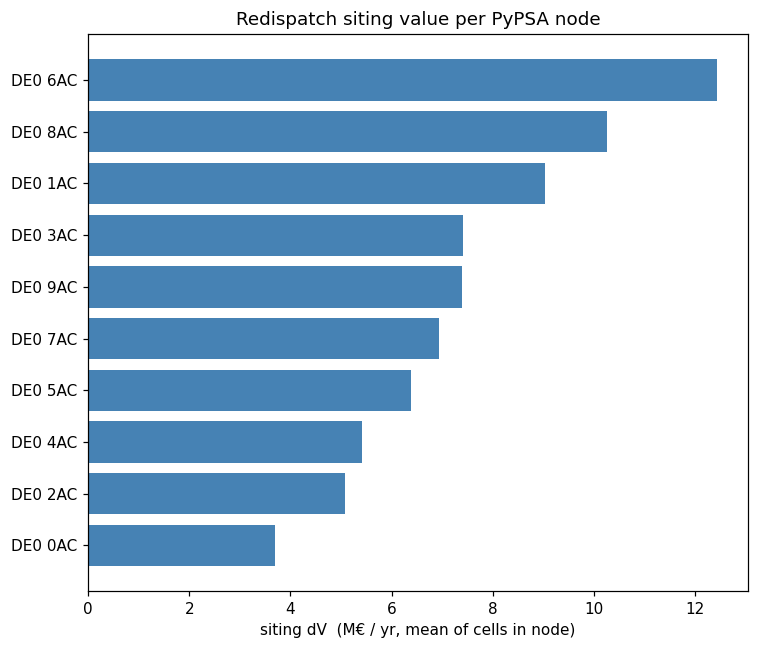

In [6]:
d=m.sort_values('sit_dV')
plt.figure(figsize=(7,6))
plt.barh(d['bus'],d['sit_dV']/1e6,color='steelblue')
plt.xlabel('siting dV  (M€ / yr, mean of cells in node)'); plt.title('Redispatch siting value per PyPSA node')
plt.tight_layout(); plt.show()

### 5b. Siting value vs. nodal-price battery value

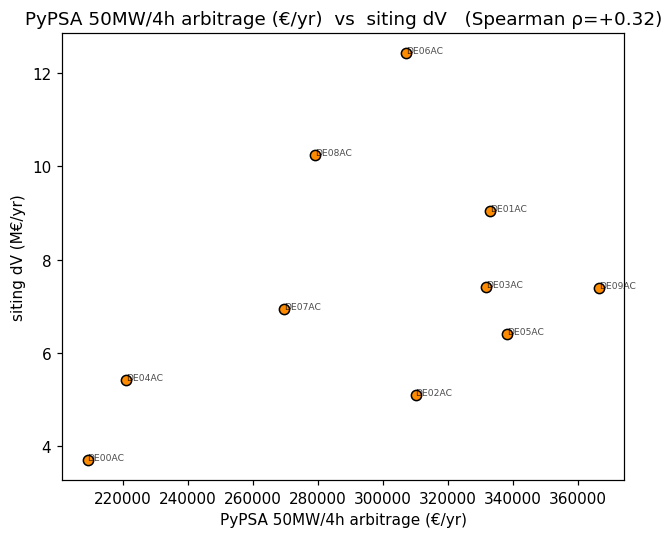

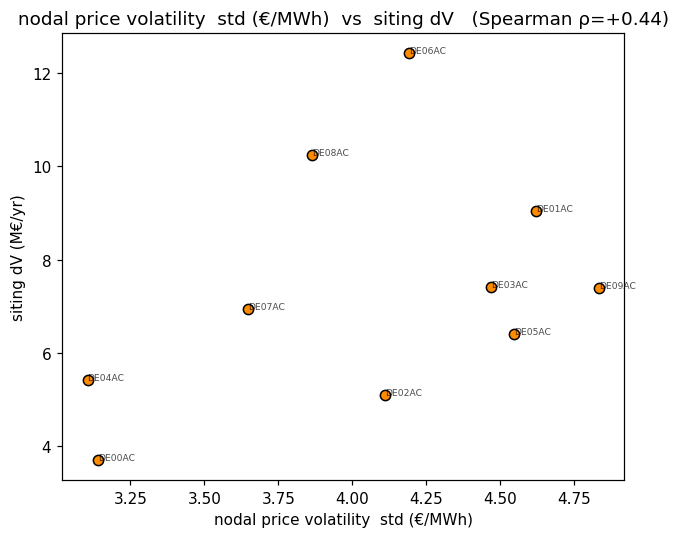

In [7]:
def scat(xc,yc,xl,yl):
    plt.figure(figsize=(6,5))
    plt.scatter(m[xc],m[yc]/1e6,c='darkorange',edgecolor='k',s=45)
    for _,r in m.iterrows(): plt.annotate(r['bus'].replace(' ','')[:6],(r[xc],r[yc]/1e6),fontsize=6,alpha=.7)
    rho,_=spearmanr(m[xc],m[yc])
    plt.xlabel(xl); plt.ylabel(yl); plt.title(f'{xl}  vs  siting dV   (Spearman ρ={rho:+.2f})')
    plt.tight_layout(); plt.show()
scat('arb_eur_yr','sit_dV','PyPSA 50MW/4h arbitrage (€/yr)','siting dV (M€/yr)')
scat('std_price','sit_dV','nodal price volatility  std (€/MWh)','siting dV (M€/yr)')

### 5c. Spatial pattern — siting value vs. nodal arbitrage side by side

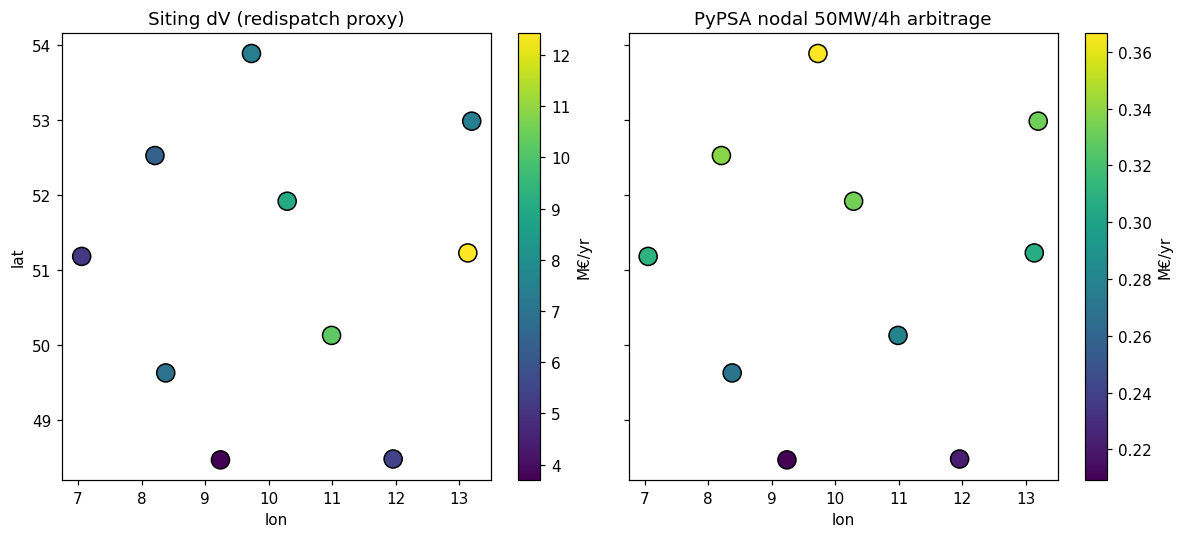

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,5),sharex=True,sharey=True)
for a,col,ttl in [(ax[0],'sit_dV','Siting dV (redispatch proxy)'),
                  (ax[1],'arb_eur_yr','PyPSA nodal 50MW/4h arbitrage')]:
    sc=a.scatter(m['x'],m['y'],c=m[col]/1e6,cmap='viridis',s=140,edgecolor='k')
    a.set_title(ttl); a.set_xlabel('lon'); fig.colorbar(sc,ax=a,label='M€/yr')
ax[0].set_ylabel('lat'); plt.tight_layout(); plt.show()

### 5d. Metric correlation heatmap

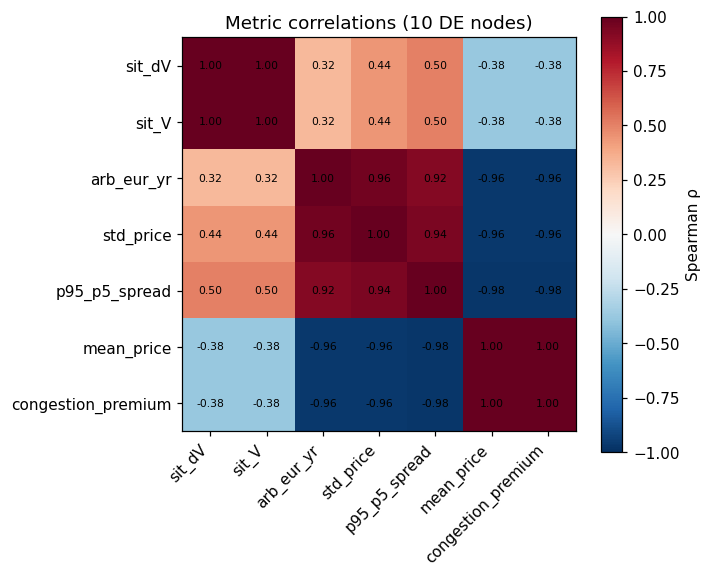

In [9]:
mc=m[['sit_dV','sit_V','arb_eur_yr','std_price','p95_p5_spread','mean_price','congestion_premium']].corr(method='spearman')
plt.figure(figsize=(6.5,5.5))
plt.imshow(mc,cmap='RdBu_r',vmin=-1,vmax=1)
plt.xticks(range(len(mc)),mc.columns,rotation=45,ha='right'); plt.yticks(range(len(mc)),mc.columns)
for i in range(len(mc)):
    for j in range(len(mc)): plt.text(j,i,f"{mc.iloc[i,j]:.2f}",ha='center',va='center',fontsize=7)
plt.colorbar(label='Spearman ρ'); plt.title('Metric correlations (10 DE nodes)'); plt.tight_layout(); plt.show()

## 6. Save results & takeaways

In [10]:
m.round(3).to_csv("nodal_vs_siting_comparison_2025.csv",index=False)
print("saved -> nodal_vs_siting_comparison_2025.csv")

saved -> nodal_vs_siting_comparison_2025.csv


**Reading the results**

- Compare **ranks**, not euros: siting `dV` is calibrated to BNetzA redispatch cost
  (~100 €/MWh); the PyPSA LMP spreads here are only a few €/MWh, so absolute levels differ
  by orders of magnitude by construction.
- A **positive** Spearman ρ between siting `dV` and nodal **arbitrage / volatility** means the
  redispatch proxy is pointing at the same high-value locations the nodal model does — the
  core validation claim for the seminar.
- Watch the **congestion_premium** sign: high *mean-price* nodes (southern demand centres)
  are not necessarily high *volatility* nodes, so mean price and battery value can diverge.
- This hourly run resolves the full intraday price shape (8760 h), so the arbitrage € is
  realistic — but it has only **10 DE nodes**, so correlations are coarse and rarely reach
  significance. Cross-check the spatial pattern against the 25-node 2013 notebook.